# 03 — Player trajectories

The breakout question is about **change**, not level: *"this player is improving unusually quickly"* rather than *"this player is good"*. This notebook adds, for every feature, how it has moved over each player's **past** seasons.

| Column | Meaning (all use seasons ≤ *t* only) |
|---|---|
| `c_prev`, `c_delta` | value in the previous season *played*, and the change since (**D13**: with `seasons_missed` recording any gap, e.g. Klay Thompson 2018-19 → 2021-22) |
| `c_roll3` | 3-season rolling average: the player's recent **level** |
| `c_slope3` | 3-season trend per season: his **direction** |
| `c_vs_past` | this season minus his previous-3-season average: how much of an **outlier** this season is for *him* |

Rolling averages and trends weight shooting percentages by their attempts and everything else by minutes, so a 49-attempt injury season barely moves a level. It still shows up in full in `c_vs_past` (**D14**: we keep what actually happened).

Career context: `seasons_played`, `career_min_to_date` (both counted from 2011-12), `seasons_missed`, and `entry_age` (age on entering the NBA = age − prior NBA seasons).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.columns import relative_columns
from unicorn.plotting import apply_style, BLUE, ORANGE, INK2, MUTED, FIG_DIR, SERIES
from unicorn.raw import PROJECT_ROOT
from unicorn.trajectories import add_trajectories

apply_style()
feat = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_features.parquet")

TRAJ_COLS = ["min"] + relative_columns() + [f"{c}_z" for c in relative_columns()]
traj = add_trajectories(feat, TRAJ_COLS)
print(f"{len(TRAJ_COLS)} base columns → {traj.shape[1] - feat.shape[1]} new columns; table {traj.shape}")

69 base columns → 349 new columns; table (7889, 549)


### Leakage test

Recompute everything on data **truncated at 2017-18**. If any column used a later season, the 2011-12 → 2017-18 rows would differ from the full build.

In [2]:
cutoff = 2017
truncated = add_trajectories(feat[feat["season_start"] <= cutoff], TRAJ_COLS).set_index(["player_id", "season"]).sort_index()
full = traj[traj["season_start"] <= cutoff].set_index(["player_id", "season"]).sort_index()
new_cols = [c for c in truncated.columns if c not in feat.columns]
pd.testing.assert_frame_equal(full[new_cols], truncated[new_cols])
print(f"✓ all {len(new_cols)} trajectory columns identical when seasons after {cutoff}-{cutoff - 1999} are removed")

✓ all 349 trajectory columns identical when seasons after 2017-18 are removed


### Examples: a gap (Klay Thompson) and an outlier season (Stephen Curry)

In [3]:
display(traj.loc[traj["player_name"] == "Klay Thompson",
                 ["season", "seasons_missed", "pts_per36", "pts_per36_prev", "pts_per36_delta", "pts_per36_roll3"]].round(2))
display(traj.loc[traj["player_name"] == "Stephen Curry",
                 ["season", "fg3a", "fg3_pct", "fg3_pct_roll3", "fg3_pct_slope3", "fg3_pct_vs_past"]].round(3))

,season,seasons_missed,pts_per36,pts_per36_prev,pts_per36_delta,pts_per36_roll3
2471,2011-12,NaN,18.50,NaN,NaN,18.50
2472,2012-13,0.0,16.66,18.50,-1.83,17.31
2473,2013-14,0.0,18.68,16.66,2.02,17.84
2474,2014-15,0.0,24.46,18.68,5.78,19.68
2475,2015-16,0.0,23.91,24.46,-0.55,22.20
2476,2016-17,0.0,23.67,23.91,-0.24,24.00
2477,2017-18,0.0,21.00,23.67,-2.67,22.90
2478,2018-19,0.0,22.80,21.00,1.80,22.52
2479,2021-22,2.0,24.95,22.80,2.15,22.39
2480,2022-23,0.0,23.84,24.95,-1.11,23.55


,season,fg3a,fg3_pct,fg3_pct_roll3,fg3_pct_slope3,fg3_pct_vs_past
1702,2011-12,121,0.455,0.455,NaN,NaN
1703,2012-13,600,0.453,0.454,-0.001,-0.001
1704,2013-14,615,0.424,0.440,-0.021,-0.029
1705,2014-15,646,0.443,0.440,-0.005,0.003
1706,2015-16,886,0.454,0.442,0.014,0.014
1707,2016-17,789,0.411,0.436,-0.017,-0.031
1708,2017-18,501,0.423,0.431,-0.018,-0.013
1709,2018-19,810,0.437,0.424,0.013,0.006
1710,2019-20,49,0.245,0.425,-0.020,-0.179
1711,2020-21,801,0.421,0.423,-0.008,-0.004


### Normal development: average season-to-season change by age

Breakouts only mean something relative to what a typical player of that age does. Sample: consecutive seasons, ≥ 500 minutes in both. ⚠️ **Survivorship bias:** players who decline sharply tend to lose minutes and fall out of the sample, so these curves are optimistic, especially at older ages.

player-season pairs per age: {20.0: 74, 21.0: 176, 22.0: 246, 23.0: 310, 24.0: 367, 25.0: 383, 26.0: 376, 27.0: 355, 28.0: 335, 29.0: 283, 30.0: 247, 31.0: 213, 32.0: 183, 33.0: 137, 34.0: 296}


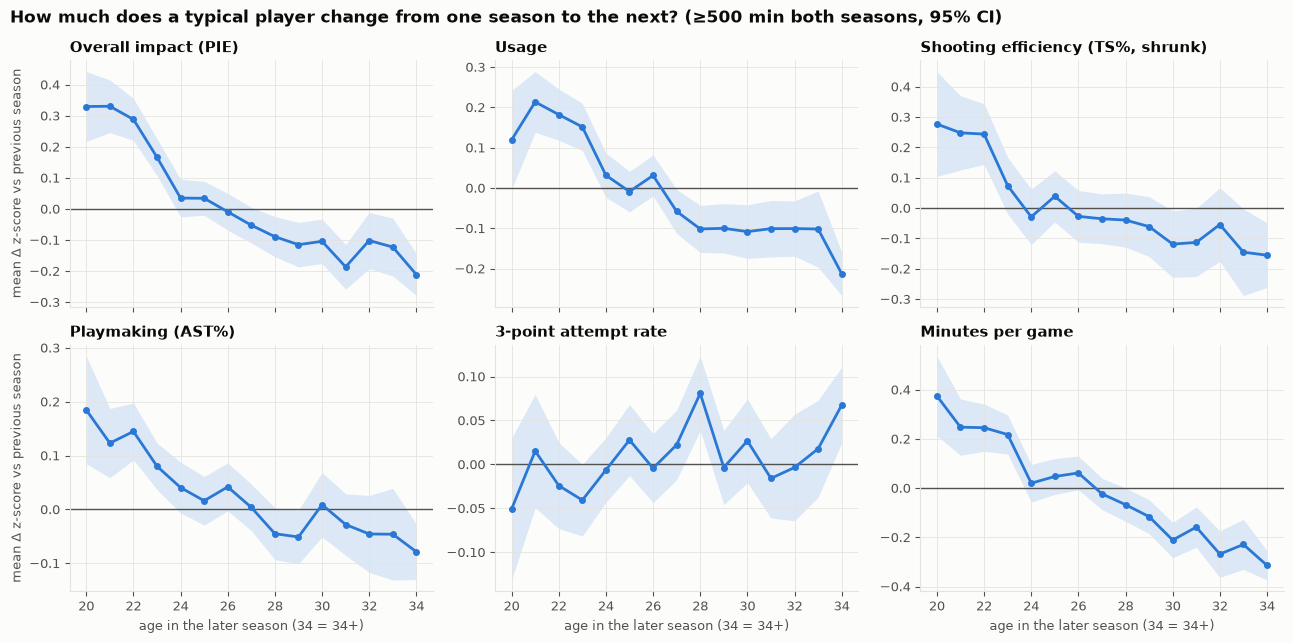

In [4]:
dev = traj[(traj["seasons_missed"] == 0) & (traj["min"] >= 500) & (traj["min_prev"] >= 500)].copy()
dev["age_int"] = np.floor(dev["age"]).clip(19, 34)
curve_cols = {"pie_z_delta": "Overall impact (PIE)", "usg_pct_z_delta": "Usage", "ts_pct_shr_z_delta": "Shooting efficiency (TS%, shrunk)",
              "ast_pct_z_delta": "Playmaking (AST%)", "fg3a_rate_z_delta": "3-point attempt rate", "min_per_game_z_delta": "Minutes per game"}
summary = dev.groupby("age_int")[list(curve_cols)].agg(["mean", "sem", "count"])

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax, (c, title) in zip(axes.flat, curve_cols.items()):
    m, se = summary[(c, "mean")], summary[(c, "sem")]
    ax.axhline(0, color=INK2, linewidth=1)
    ax.fill_between(m.index, m - 1.96 * se, m + 1.96 * se, color=BLUE, alpha=0.15, linewidth=0)
    ax.plot(m.index, m, color=BLUE, marker="o", markersize=4)
    ax.set_title(title, loc="left")
for ax in axes[1]:
    ax.set_xlabel("age in the later season (34 = 34+)")
for ax in axes[:, 0]:
    ax.set_ylabel("mean Δ z-score vs previous season")
fig.suptitle("How much does a typical player change from one season to the next? (≥500 min both seasons, 95% CI)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_development_by_age.png", dpi=150, bbox_inches="tight")
print("player-season pairs per age:", summary[("pie_z_delta", "count")].astype(int).to_dict())

### What did Shai and LaMelo look like before they broke out?

Aligned by NBA season number (1 = rookie year), on season-relative z-scores (0 = average rotation player that season).

Shai Gilgeous-Alexander


,season,seasons_played,age,min_per_game,pie_z,pie_z_delta,usg_pct_z,ts_pct_shr_z,ast_pct_z,pct_uast_fgm_z
5588,2018-19,1,20.56,26.51,-0.40,NaN,-0.09,-0.17,0.40,1.31
5589,2019-20,2,21.56,34.69,0.79,1.19,0.88,0.05,0.05,1.94
5590,2020-21,3,22.56,33.70,1.57,0.77,1.73,0.97,1.92,2.97
5591,2021-22,4,23.56,34.68,1.22,-0.35,2.08,-0.24,1.69,2.77
5592,2022-23,5,24.56,35.53,2.47,1.26,2.36,0.98,1.23,2.60
5593,2023-24,6,25.56,34.04,2.99,0.52,2.39,1.32,1.61,2.75
5594,2024-25,7,26.56,34.18,3.41,0.42,2.70,1.51,1.73,2.75
5595,2025-26,8,27.56,33.22,3.60,0.19,2.49,1.90,2.09,3.09


LaMelo Ball


,season,seasons_played,age,min_per_game,pie_z,pie_z_delta,usg_pct_z,ts_pct_shr_z,ast_pct_z,pct_uast_fgm_z
6453,2020-21,1,19.45,28.80,0.76,NaN,1.07,-0.69,2.05,1.29
6454,2021-22,2,20.45,32.29,1.15,0.39,1.57,-0.30,2.25,1.06
6455,2022-23,3,21.45,35.22,0.82,-0.33,1.85,-0.84,2.44,1.21
6456,2023-24,4,22.44,32.33,1.22,0.40,2.35,-0.45,2.90,2.22
6457,2024-25,5,23.45,32.01,0.99,-0.23,2.80,-0.93,2.83,1.70
6458,2025-26,6,24.45,28.02,1.19,0.21,2.18,-0.78,2.70,1.42


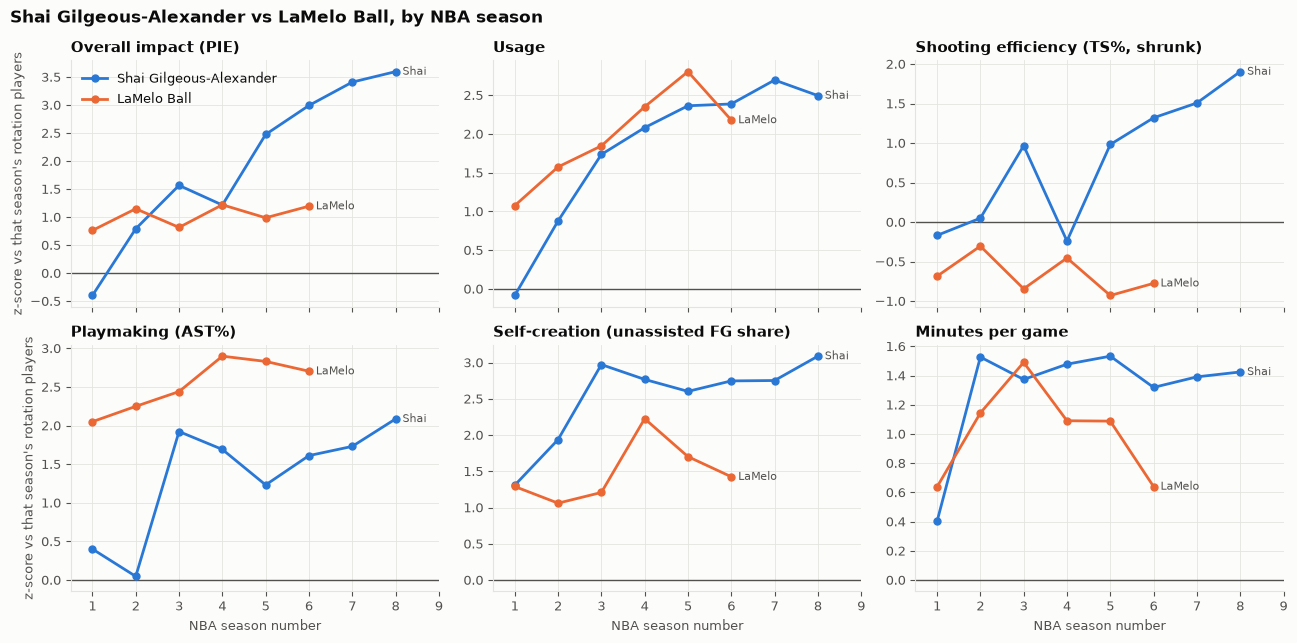

In [5]:
players = {"Shai Gilgeous-Alexander": SERIES[0], "LaMelo Ball": SERIES[1]}
panels = {"pie_z": "Overall impact (PIE)", "usg_pct_z": "Usage", "ts_pct_shr_z": "Shooting efficiency (TS%, shrunk)",
          "ast_pct_z": "Playmaking (AST%)", "pct_uast_fgm_z": "Self-creation (unassisted FG share)", "min_per_game_z": "Minutes per game"}

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax, (c, title) in zip(axes.flat, panels.items()):
    ax.axhline(0, color=INK2, linewidth=1)
    for name, color in players.items():
        d = traj[traj["player_name"] == name]
        ax.plot(d["seasons_played"], d[c], color=color, marker="o", markersize=5, label=name)
        ax.annotate(name.split()[0], (d["seasons_played"].iloc[-1], d[c].iloc[-1]), xytext=(5, 0),
                    textcoords="offset points", va="center", color=INK2, fontsize=8)
    ax.set_title(title, loc="left")
    ax.set_xlim(0.5, 9)
for ax in axes[1]:
    ax.set_xlabel("NBA season number")
for ax in axes[:, 0]:
    ax.set_ylabel("z-score vs that season's rotation players")
axes[0, 0].legend(frameon=False, loc="upper left")
fig.suptitle("Shai Gilgeous-Alexander vs LaMelo Ball, by NBA season", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_sga_vs_lamelo.png", dpi=150, bbox_inches="tight")

cols = ["season", "seasons_played", "age", "min_per_game", "pie_z", "pie_z_delta", "usg_pct_z", "ts_pct_shr_z", "ast_pct_z", "pct_uast_fgm_z"]
for name in players:
    print(name); display(traj.loc[traj["player_name"] == name, cols].round(2))

In [6]:
traj.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_trajectories.parquet", index=False)
print("saved player_season_trajectories.parquet", traj.shape)

saved player_season_trajectories.parquet (7889, 549)


### Step 3 findings

- **349 trajectory columns, verified leakage-free:** they are identical when every season after 2017-18 is deleted.
- **Normal development (the baseline a breakout must beat):**
  - Age 20–22: overall impact (PIE z) rises by about **+0.3 per season**, minutes by +0.25–0.4, efficiency by +0.25, usage by +0.15–0.2.
  - Gains stop around **24**. Decline sets in from about **27–28**, and these curves are optimistic at older ages because of survivorship.
  - 3PA rate relative to the league shows no age pattern. Players don't systematically become more 3-point-heavy than their peers as they age; the league-wide rise is removed by the z-scoring.
- **Shai vs LaMelo, read through that baseline:**
  - Shai's PIE jumps of **+1.19 (season 2)** and **+1.26 (season 5)** are about **4× normal for his age**. Those are the breakouts we want to detect.
  - In his rookie year Shai's overall impact was *below average* (PIE z −0.40). An impact-based screen would have missed him. **Self-creation was already +1.3 z and rose to +1.9 in year 2, and usage climbed steeply.**
  - LaMelo out-assisted Shai every season and had higher usage early. The separating trait is **efficiency**: Shai's shrunk TS% went from −0.2 to +1.9 z, while LaMelo's has stayed between −0.3 and −0.9.
  - **Hypothesis for 05/06** (to test, not to assume): usage growth + self-creation predict *role* breakouts; efficiency *at* rising usage separates stars from high-volume players.